# Calibration & PnL analysis

This notebook loads the saved predictions snapshot, computes market-implied probability, edge and EV per unit, and constructs a simple PnL (1-unit stake) pipeline. It produces cumulative PnL plots for fixed probability thresholds (0.50, 0.60, 0.70) and a threshold sweep (0.30→0.80) that records #bets, wins, win_rate, total PnL and ROI. The code also fits two probability calibrators — Platt (logistic regression) and isotonic regression — using a stratified train/test split on known rows, compares Brier scores, plots calibration curves, and writes a calibrated snapshot with new probability columns.

Key numeric outputs (from this run)
- Brier (test split): raw 0.24675699285582114, Platt 0.2369048270683485, Isotonic 0.24628221433718  
- Brier (all known rows): raw 0.2382755586296266, Platt 0.23264830677491685, Isotonic 0.22205074932752336  
Interpretation: on the held-out test split Platt provided the largest Brier improvement vs raw probabilities, while isotonic produced the best Brier when evaluated on the full set of known rows. This suggests isotonic can give better overall calibration on the available data but may be more sensitive to the fit set; Platt is more stable on the random test split. Inspect the calibration curve (saved) to see where each method over/under‑predicts.

Business-relevant outputs and practical notes
- The notebook saves: cumulative PnL plot for thresholds, threshold sweep CSV (raw), and threshold sweep CSVs for raw / Platt / Isotonic as well as a combined calibrated snapshot: results/predictions_snapshot_with_calibrated_probs.csv. These CSVs are the primary artefacts to pick an operating threshold and to simulate ROI. Use the threshold_sweep_* CSVs to choose a threshold consistent with your business preference (high precision / fewer picks vs higher recall / more picks). The cumulative_pnl_raw_vs_calibrated plot shows how calibration affects realized PnL over time for the selected thresholds.

In [5]:
import numpy as np, pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

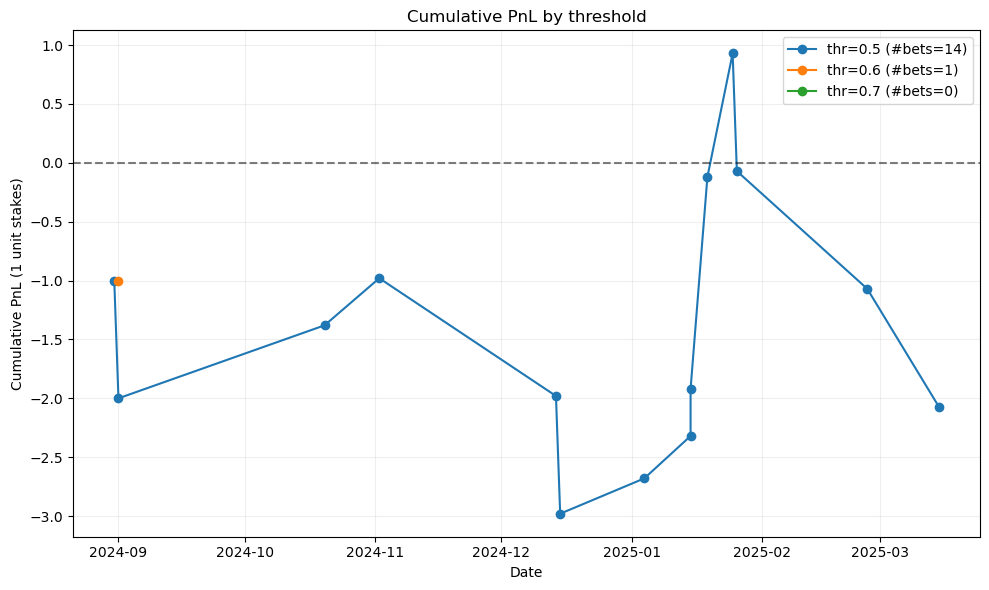

Saved threshold_sweep_metrics_raw.csv and cumulative plot -> results


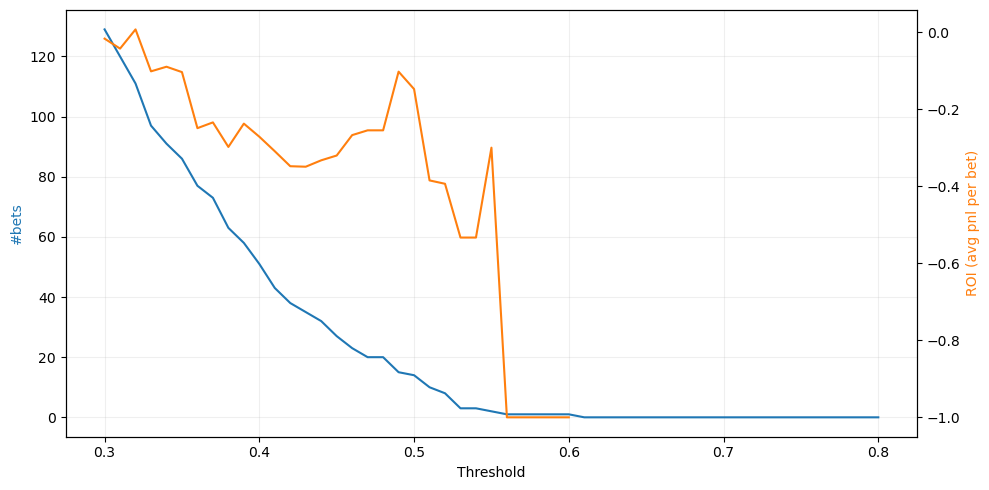

In [6]:
SNAP = Path("../../data/processed/predictions_snapshot_20251109T143856Z.csv") 
OUT = Path("results"); OUT.mkdir(exist_ok=True, parents=True)

df = pd.read_csv(SNAP, parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

if 'actual' in df.columns:
    df['actual'] = pd.to_numeric(df['actual'], errors='coerce')

df['implied'] = 1.0 / df['odds_B365H'].replace(0, np.nan)
df['edge'] = df['prob_home'] - df['implied']
df['ev_per_unit'] = df['odds_B365H'] * df['prob_home'] - 1.0

def pnl_1unit(row):
    if pd.isna(row.get('actual')):
        return np.nan
    return (row['odds_B365H'] - 1) if row['actual'] == 1 else -1
df['pnl_1unit'] = df.apply(pnl_1unit, axis=1)

thresholds = [0.50, 0.60, 0.70]
plt.figure(figsize=(10,6))
for t in thresholds:
    sel = df[df['prob_home'] >= t].sort_values('date')
    sel = sel[sel['pnl_1unit'].notna()]
    cum = sel['pnl_1unit'].cumsum()
    plt.plot(sel['date'], cum, marker='o' if len(sel)<=30 else None, label=f"thr={t} (#bets={len(sel)})")
plt.axhline(0, color='k', linestyle='--', alpha=0.5)
plt.xlabel("Date"); plt.ylabel("Cumulative PnL (1 unit stakes)")
plt.title("Cumulative PnL by threshold")
plt.legend(); plt.grid(alpha=0.2); plt.tight_layout()
plt.savefig(OUT / "cumulative_pnl_by_threshold_050_060_070.png")
plt.show()

grid = np.linspace(0.30, 0.80, 51)
rows = []
for t in grid:
    sel = df[df['prob_home'] >= t]
    n = len(sel)
    wins = int(sel['actual'].sum()) if 'actual' in sel.columns and n>0 else np.nan
    win_rate = wins / n if n>0 and not np.isnan(wins) else np.nan
    total_pnl = sel['pnl_1unit'].sum(skipna=True) if n>0 else np.nan
    roi = total_pnl / n if n>0 else np.nan
    rows.append({"threshold": float(t), "n_bets": int(n), "wins": wins, "win_rate": float(win_rate) if not np.isnan(win_rate) else np.nan, "total_pnl": float(total_pnl) if not np.isnan(total_pnl) else np.nan, "roi": float(roi) if not np.isnan(roi) else np.nan, "avg_edge": float(sel['edge'].mean()) if n>0 else np.nan})
res = pd.DataFrame(rows)
res.to_csv(OUT / "threshold_sweep_metrics_raw.csv", index=False)
print("Saved threshold_sweep_metrics_raw.csv and cumulative plot ->", OUT)

fig, ax1 = plt.subplots(figsize=(10,5))
ax1.plot(res['threshold'], res['n_bets'], color='tab:blue', label='#bets')
ax1.set_xlabel('Threshold'); ax1.set_ylabel('#bets', color='tab:blue')
ax2 = ax1.twinx()
ax2.plot(res['threshold'], res['roi'], color='tab:orange', label='ROI')
ax2.set_ylabel('ROI (avg pnl per bet)', color='tab:orange')
ax1.grid(alpha=0.2)
fig.tight_layout()
plt.savefig(OUT / "threshold_vs_metrics_raw.png")
plt.show()

Brier (raw): 0.24675699285582114 Platt: 0.2369048270683485 Isotonic: 0.24628221433718


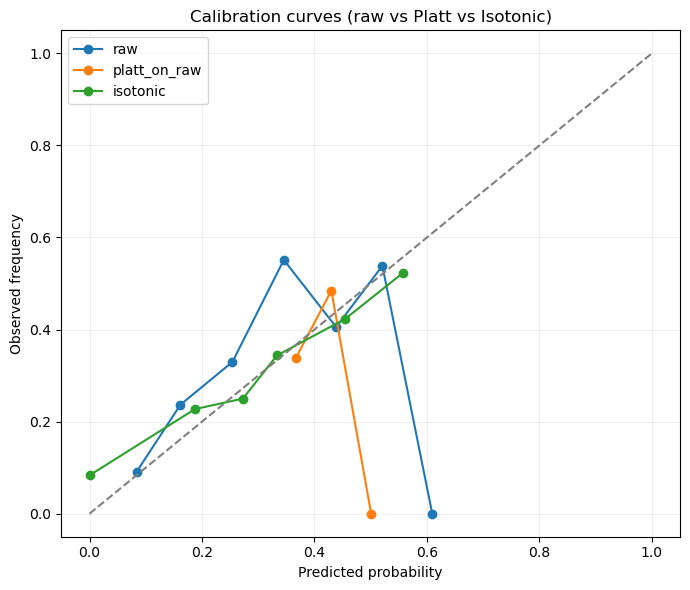

Brier scores on all known rows: raw 0.2382755586296266 platt 0.23264830677491685 isotonic 0.22205074932752336
Saved calibrated snapshot to results/


In [7]:
df = pd.read_csv(SNAP, parse_dates=["date"])
known = df[df['actual'].notna()].copy()
y = known['actual'].astype(int)
p_raw = known['prob_home'].astype(float)

X = p_raw.values.reshape(-1,1)
X_train, X_test, y_train, y_test = train_test_split(X, y.values, test_size=0.3, random_state=42, stratify=y)
p_train = X_train.ravel(); p_test = X_test.ravel()

platt = LogisticRegression(solver='lbfgs')
platt.fit(p_train.reshape(-1,1), y_train)
p_platt_test = platt.predict_proba(p_test.reshape(-1,1))[:,1]

iso = IsotonicRegression(out_of_bounds='clip')
iso.fit(p_train, y_train)
p_iso_test = iso.predict(p_test)

brier_raw = brier_score_loss(y_test, p_test)
brier_platt = brier_score_loss(y_test, p_platt_test)
brier_iso = brier_score_loss(y_test, p_iso_test)
print("Brier (raw):", brier_raw, "Platt:", brier_platt, "Isotonic:", brier_iso)

from sklearn.calibration import calibration_curve
plt.figure(figsize=(7,6))
for name, probs in [("raw", p_raw), ("platt_on_raw", platt.predict_proba(p_raw.values.reshape(-1,1))[:,1]), ("isotonic", iso.predict(p_raw.values))]:
    prob_true, prob_pred = calibration_curve(y, probs, n_bins=10)
    plt.plot(prob_pred, prob_true, marker='o', label=f"{name}")
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("Predicted probability"); plt.ylabel("Observed frequency")
plt.title("Calibration curves (raw vs Platt vs Isotonic)")
plt.legend(); plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(OUT / "calibration_curves_raw_platt_isotonic.png")
plt.show()

df['prob_platt'] = platt.predict_proba(df['prob_home'].values.reshape(-1,1))[:,1]
df['prob_isotonic'] = iso.predict(df['prob_home'].values)

known_full = df[df['actual'].notna()].copy()
print("Brier scores on all known rows: raw", brier_score_loss(known_full['actual'], known_full['prob_home']),
      "platt", brier_score_loss(known_full['actual'], known_full['prob_platt']),
      "isotonic", brier_score_loss(known_full['actual'], known_full['prob_isotonic']))

df.to_csv(OUT / "predictions_snapshot_with_calibrated_probs.csv", index=False)
print("Saved calibrated snapshot to results/")

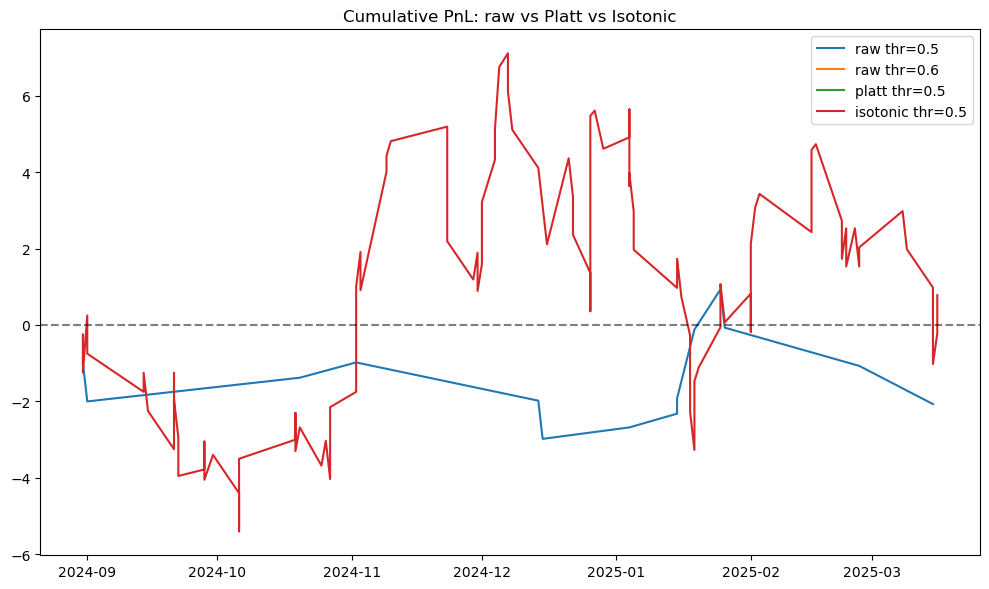

Saved threshold sweep CSVs for raw/platt/isotonic to results/


In [8]:
def compute_threshold_metrics(df_probs, label):
    dfc = df.copy()
    dfc['prob'] = df_probs
    dfc['edge'] = dfc['prob'] - (1.0 / dfc['odds_B365H'].replace(0, np.nan))
    dfc['pnl_1unit'] = dfc.apply(lambda r: (r['odds_B365H'] - 1) if r.get('actual')==1 else (-1 if not pd.isna(r.get('actual')) else np.nan), axis=1)
    grid = np.linspace(0.30, 0.80, 51)
    rows = []
    for t in grid:
        sel = dfc[dfc['prob'] >= t]
        n = len(sel)
        total_pnl = sel['pnl_1unit'].sum(skipna=True) if n>0 else np.nan
        rows.append({'threshold':float(t),'n_bets':int(n),'total_pnl':float(total_pnl) if not pd.isna(total_pnl) else np.nan,'avg_edge':float(sel['edge'].mean()) if n>0 else np.nan})
    return pd.DataFrame(rows)

res_raw = compute_threshold_metrics(df['prob_home'], 'raw')
res_platt = compute_threshold_metrics(df['prob_platt'], 'platt')
res_iso = compute_threshold_metrics(df['prob_isotonic'], 'isotonic')

plt.figure(figsize=(10,6))
for probs, name in [(df['prob_home'],'raw'), (df['prob_platt'],'platt'), (df['prob_isotonic'],'isotonic')]:
    for t in [0.5,0.6,0.7]:
        sel = df[probs >= t].sort_values('date')
        sel = sel[sel['actual'].notna()]
        cum = sel.apply(lambda r: (r['odds_B365H'] - 1) if r['actual']==1 else -1, axis=1).cumsum()
        if len(cum)>0:
            plt.plot(sel['date'], cum, label=f"{name} thr={t}")
plt.axhline(0, color='k', linestyle='--', alpha=0.5)
plt.legend(); plt.title("Cumulative PnL: raw vs Platt vs Isotonic"); plt.tight_layout()
plt.savefig(OUT / "cumulative_pnl_raw_vs_calibrated.png")
plt.show()

res_raw.to_csv(OUT / "threshold_sweep_raw.csv", index=False)
res_platt.to_csv(OUT / "threshold_sweep_platt.csv", index=False)
res_iso.to_csv(OUT / "threshold_sweep_isotonic.csv", index=False)
print("Saved threshold sweep CSVs for raw/platt/isotonic to results/")

In [9]:
import joblib, os
os.makedirs("models/calibrators", exist_ok=True)
joblib.dump(platt, "models/calibrators/platt_calibrator.joblib")
joblib.dump(iso, "models/calibrators/isotonic_calibrator.joblib")

['models/calibrators/isotonic_calibrator.joblib']